In [13]:
!apt-get update -qq
!apt-get install -y -qq r-base libcurl4-openssl-dev libssl-dev libxml2-dev libfontconfig1-dev libharfbuzz-dev libfribidi-dev libfreetype6-dev libpng-dev libtiff5-dev libjpeg-dev libfftw3-dev

!R -e "install.packages('BiocManager', repos='https://cloud.r-project.org')"

!pip install -q rpy2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libfftw3-double3:amd64.
(Reading database ... 118471 files and directories currently installed.)
Preparing to unpack .../0-libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package libfftw3-long3:amd64.
Preparing to unpack .../1-libfftw3-long3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-long3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package libfftw3-quad3:amd64.
Preparing to unpack .../2-libfftw3-quad3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-quad3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package libfftw3-single3:amd64.
Preparing to unpack .../3-libfftw3-single3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-single3:amd64 (3.3.8-2ubu

In [14]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [15]:
from google.colab import files

uploaded = files.upload()

Saving c1.jpg to c1 (3).jpg
Saving c2.jpg to c2 (3).jpg
Saving c3.jpg to c3 (3).jpg
Saving c4.jpg to c4 (3).jpg
Saving c5.jpg to c5 (3).jpg
Saving c6.jpg to c6 (3).jpg
Saving p1.jpg to p1 (2).jpg
Saving p2.jpg to p2 (2).jpg
Saving p3.jpg to p3 (2).jpg
Saving p4.jpg to p4 (2).jpg
Saving p5.jpg to p5 (2).jpg
Saving p6.jpg to p6 (2).jpg


In [16]:
%%R

# Install BiocManager if not already installed in the current R session
if (!requireNamespace("BiocManager", quietly = TRUE)) {
    install.packages("BiocManager", repos = "https://cloud.r-project.org")
}

# Install EBImage and keras using BiocManager if not already installed
# This ensures they are available to the rpy2-managed R session
if (!requireNamespace("EBImage", quietly = TRUE)) {
    BiocManager::install("EBImage", ask = FALSE, update = FALSE)
}
if (!requireNamespace("keras", quietly = TRUE)) {
    install.packages("keras", repos = "https://cloud.r-project.org")
}

# Load Packages
library(EBImage)
library(keras)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)
Installing package(s) 'EBImage'
also installing the dependency ‘fftwtools’

trying URL 'https://cran.rstudio.com/src/contrib/fftwtools_0.9-11.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/EBImage_4.54.0.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpTPBC2p/downloaded_packages’
The keras package is deprecated. Please use the keras3 package instead.
Alternatively, to continue using legacy keras, call `py_require_legacy_keras()`.

Attaching package: ‘keras’

The following object is masked from ‘package:EBImage’:

    normalize



In [17]:
%%R

pics <- c(
  'p1.jpg', 'p2.jpg', 'p3.jpg',
  'p4.jpg', 'p5.jpg', 'p6.jpg',
  'c1.jpg', 'c2.jpg', 'c3.jpg',
  'c4.jpg', 'c5.jpg', 'c6.jpg'
)

mypic <- list()

for (i in 1:12) {
  mypic[[i]] <- readImage(file.path('/content', pics[i]))
}

Image 
  colorMode    : Color 
  storage.mode : double 
  dim          : 281 180 3 
  frames.total : 3 
  frames.render: 1 

imageData(object)[1:5,1:6,1]
     [,1] [,2] [,3] [,4] [,5] [,6]
[1,]    1    1    1    1    1    1
[2,]    1    1    1    1    1    1
[3,]    1    1    1    1    1    1
[4,]    1    1    1    1    1    1
[5,]    1    1    1    1    1    1
List of 12
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:281, 1:180, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 281 180 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:272, 1:185, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 272 185 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:341, 1:148, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 341 148 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ 

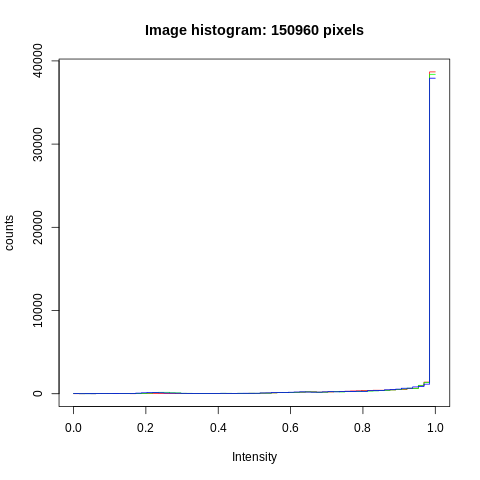

In [18]:
%%R

print(mypic[[1]])

display(mypic[[8]])

summary(mypic[[1]])

hist(mypic[[2]])

str(mypic)

In [20]:
%%R
input_shape = c(2352)

In [21]:
%%R

for (i in 1:12) {
  mypic[[i]] <- resize(mypic[[i]], 28, 28)
}

In [22]:
%%R

for (i in 1:12) {
  mypic[[i]] <- array_reshape(mypic[[i]], c(28, 28, 3))
}

In [23]:
%%R

trainx <- NULL

for (i in c(1:5, 7:11)) {
  trainx <- rbind(trainx, as.vector(mypic[[i]]))
}

str(trainx)

testx <- rbind(
  as.vector(mypic[[6]]),
  as.vector(mypic[[12]])
)

trainy <- c(0, 0, 0, 0, 0,
            1, 1, 1, 1, 1)

testy <- c(0, 1)

 num [1:10, 1:2352] 1 1 1 0.26 0.49 ...


In [28]:
%%R

# Manual One-Hot Encoding for trainy
num_samples_train <- length(trainy)
trainLabels <- matrix(0, nrow = num_samples_train, ncol = 2)
for (i in 1:num_samples_train) {
  trainLabels[i, trainy[i] + 1] <- 1
}

# Manual One-Hot Encoding for testy
num_samples_test <- length(testy)
testLabels <- matrix(0, nrow = num_samples_test, ncol = 2)
for (i in 1:num_samples_test) {
  testLabels[i, testy[i] + 1] <- 1
}

In [35]:
%%R

# Model definition moved to cell X2RfrBQ40XX_ for better scope management.
# This cell is now empty as its content has been moved.

NULL


In [39]:
%%R

library(keras)
library(reticulate) # Ensure reticulate is loaded for py_get_attr

model <- keras_model_sequential(
  list(
    layer_input(shape = c(2352)), # Explicitly define input layer
    layer_dense(
      units = 256,
      activation = 'relu'
    ),
    layer_dense(
      units = 128,
      activation = 'relu'
    ),
    layer_dense(
      units = 2,
      activation = 'softmax'
    )
  )
)

summary(model)

# Directly call the Python 'compile' method using reticulate
model_compile_fn <- py_get_attr(model, "compile")
model_compile_fn(
  loss = 'categorical_crossentropy',
  optimizer = optimizer_rmsprop(),
  metrics = list('accuracy') # Changed c('accuracy') to list('accuracy')
)

<Sequential name=sequential_6, built=True>


In [50]:
%%R

# Manually split data for training and validation
num_samples <- nrow(trainx)
validation_idx <- sample(num_samples, round(num_samples * 0.2))

x_train_actual <- trainx[-validation_idx, , drop = FALSE]
y_train_actual <- trainLabels[-validation_idx, , drop = FALSE]

x_val <- trainx[validation_idx, , drop = FALSE]
y_val <- trainLabels[validation_idx, , drop = FALSE]

# Directly call the Python 'fit' method using reticulate
model_fit_fn <- py_get_attr(model, "fit")

history <- model_fit_fn(
    x = x_train_actual,
    y = y_train_actual,
    epochs = as.integer(30),
    batch_size = as.integer(2),
    validation_data = list(x_val, y_val) # Pass validation data explicitly
  )

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5000 - loss: 9.3450
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.5000 - loss: 9.3450 - val_accuracy: 0.5000 - val_loss: 0.5230
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 2.4414
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5000 - loss: 2.4414 - val_accuracy: 1.0000 - val_loss: 0.4115
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8750 - loss: 0.7391
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8750 - loss: 0.7391 - val_accuracy: 0.5000 - val_loss: 0.5249
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.4098
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7500 - loss: 0.4098 - val_accuracy: 0.5000 - val_loss: 0.7265
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 1.1052 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 1.1052 - val_accuracy: 1.0000 - val_loss: 0.1306
Epoch 6/30
4/

In [52]:
%%R

# Get the Python evaluate function from the model object
model_evaluate_fn <- py_get_attr(model, "evaluate")

# Evaluate on training data
metrics_train <- model_evaluate_fn(x = trainx, y = trainLabels)
cat("\nTraining Evaluation:\n")
print(metrics_train)

# Evaluate on test data
metrics_test <- model_evaluate_fn(x = testx, y = testLabels)
cat("\nTest Evaluation:\n")
print(metrics_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 1.0000 - loss: 0.0011
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 1.0000 - loss: 0.0011

Training Evaluation:
[1] 0.001138926 1.000000000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0018
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.0018

Test Evaluation:
[1] 0.001805702 1.000000000


In [54]:
%%R

# Get the Python predict function from the model object
model_predict_fn <- py_get_attr(model, "predict")

# --- Predictions on Training Data ---
prob_train <- model_predict_fn(x = trainx)
pred_train <- max.col(prob_train) - 1

cat("\nTraining Data Confusion Matrix:\n")
print(table(
  Predicted = pred_train,
  Actual = trainy
))

# --- Predictions on Test Data ---
prob_test <- model_predict_fn(x = testx)
pred_test <- max.col(prob_test) - 1

cat("\nTest Data Confusion Matrix:\n")
print(table(
  Predicted = pred_test,
  Actual = testy
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Training Data Confusion Matrix:
         Actual
Predicted 0 1
        0 5 0
        1 0 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Test Data Confusion Matrix:
         Actual
Predicted 0 1
        0 1 0
        1 0 1


In [56]:
%%R

cat("\nCombined Training Data Predictions:\n")
print(cbind(
  Probabilities = prob_train,
  Predicted = pred_train,
  Actual = trainy
))

cat("\nCombined Test Data Predictions:\n")
print(cbind(
  Probabilities = prob_test,
  Predicted = pred_test,
  Actual = testy
))


Combined Training Data Predictions:
                                Predicted Actual
 [1,] 9.999598e-01 4.012927e-05         0      0
 [2,] 9.999266e-01 7.332242e-05         0      0
 [3,] 9.998329e-01 1.672498e-04         0      0
 [4,] 9.995375e-01 4.624327e-04         0      0
 [5,] 9.998627e-01 1.373193e-04         0      0
 [6,] 1.279133e-04 9.998722e-01         1      1
 [7,] 1.103883e-04 9.998896e-01         1      1
 [8,] 9.291423e-03 9.907085e-01         1      1
 [9,] 7.848458e-05 9.999216e-01         1      1
[10,] 8.567063e-04 9.991432e-01         1      1

Combined Test Data Predictions:
                              Predicted Actual
[1,] 0.999952316 4.768947e-05         0      0
[2,] 0.003557413 9.964426e-01         1      1
